# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely **K-Nearest Neighbors (KNN)**, **Logistic Regression**, **Decision Trees**, and **Support Vector Machines (SVM)**. We will utilize a dataset related to marketing bank products (long-term term deposits) over the telephone from a Portuguese banking institution.

---

### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing). The data is from a Portuguese banking institution and is a collection of the results of multiple marketing campaigns. We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) (Moro, Laureano & Cortez, 2011) for more information on the data and features.


### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper (`CRISP-DM-BANK.pdf`). How many marketing campaigns does this data represent?


#### Answer:
Based on the **Materials and Methods** section (Page 2) of the accompanying research paper (*Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology* by Sérgio Moro, Raul M. S. Laureano, and Paulo Cortez):

1. **Number of Marketing Campaigns**: The dataset represents **17 marketing campaigns** conducted by the Portuguese bank between **May 2008 and November 2010**.
2. **Total Original Contacts**: During these 17 campaigns, a total of **79,354 phone contacts** were recorded.
3. **Filtered Dataset**: After removing missing values (na.omit), discarding non-conclusive contacts, and selecting relevant features, the final dataset analyzed in the paper was reduced from 79,354 contacts down to 45,211 instances with 29 input attributes and 1 binary target output (seems to be titled 'y').


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.


In [179]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16, 'axes.titlesize': 14})

# Load the dataset
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

# Inspect the head of the DataFrame
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```


In [180]:
df.info()

# Check for explicit missing (NaN) values
print("\n--- Explicit NaN Values ---")
print(df.isna().sum())

# Check for 'unknown' entries
print("\n--- Categorical 'unknown' Value Counts ---")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col:15s}: {unknown_count:5d} ({unknown_count/len(df)*100:.2f}%)")

# Check Target Distribution
print("\n--- Target Variable (y) Distribution ---")
print(df['y'].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#### Feature & Data Quality Summary:
1. **Missing Values**: There are **0 NaN/null values** in pandas (`df.isna().sum()` returns 0 for all columns).
2. **Counts of 'unknown'**: Categorical columns encode missing information as the string label `'unknown'`:
   - `default`: 8,597 unknowns (**20.87%**)
   - `education`: 1,731 unknowns (**4.20%**)
   - `housing`: 990 unknowns (**2.40%**)
   - `loan`: 990 unknowns (**2.40%**)
   - `job`: 330 unknowns (**0.80%**)
   - `marital`: 80 unknowns (**0.19%**)
   *Note*: Let's treat these `'unknown'` labels as a distinct categorical state during One-Hot Encoding.
3. **Target Variable (`y`)**: Binary string column (`'yes'` / `'no'`). should be coerced to numeric binary format (`1` for `'yes'`, `0` for `'no'`). The dataset shows class imbalance: **88.73% 'no'** vs **11.27% 'yes'**.
4. **Special Notes**:
   - `duration`: Highly predictive of target subscription but unknown before a call takes place. Must be evaluated separately for realistic pre-call deployment vs benchmark performance.
   - Economic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are continuous numbers.


#### Data deep dive

Before moving on, let us look more closely at how subscription rates vary across customer segments. This grounds the business findings later in the notebook in measured evidence rather than intuition.

In [181]:
# Descriptive statistics for every numeric feature
display(df.describe())

# Contact counts: how the response rate decays with repeated calls within a campaign.
# Capped at 10 because the tail out to 56 contacts is too thin to read.
print("--- Subscription Rate by Number of Campaign Contacts ---")
display(df[df['campaign'] <= 10]
        .assign(subscribed=(df['y'] == 'yes').astype(int))
        .groupby('campaign')['subscribed']
        .agg(Contacts='size', Subscription_Rate_Pct=lambda s: s.mean() * 100)
        .round(2))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


--- Subscription Rate by Number of Campaign Contacts ---


,Contacts,Subscription_Rate_Pct
campaign,,
1,17642,13.04
2,10570,11.46
3,5341,10.75
4,2651,9.39
5,1599,7.50
6,979,7.66
7,629,6.04
8,400,4.25
9,283,6.01


In [182]:
# Before doing modeling, let's use concepts learned in earlier lectures to get some feeling for factors affecting our target
subscribed = (df['y'] == 'yes').astype(int)
overall_rate = subscribed.mean()
print(f"Overall subscription rate: {overall_rate*100:.2f}%\n")

# Subscription rate by job
job_rates = (df.assign(subscribed=subscribed) #using assign to keep df clean
               .groupby('job')['subscribed']
               .agg(Contacts='size', Subscription_Rate_Pct=lambda s: s.mean() * 100) #using lambdas to get the rate for more compact code
               .sort_values('Subscription_Rate_Pct', ascending=False)
               .round(2))
print("--- Subscription Rate by Job ---")
display(job_rates)

# Subscription rate by age band
# Using bins
age_bands = pd.cut(df['age'], bins=[16, 30, 40, 50, 60, 100],
                   labels=['17-30', '31-40', '41-50', '51-60', 'Over 60'])
age_rates = (df.assign(subscribed=subscribed, age_band=age_bands)
               .groupby('age_band', observed=True)['subscribed']
               .agg(Contacts='size', Subscription_Rate_Pct=lambda s: s.mean() * 100)
               .round(2))
print("--- Subscription Rate by Age Band ---")
display(age_rates)

# Subscription rate by previous campaign outcome
print("--- Subscription Rate by Previous Campaign Outcome ---")
poutcome_rates = (df.assign(subscribed=subscribed)
                    .groupby('poutcome')['subscribed']
                    .agg(Contacts='size', Subscription_Rate_Pct=lambda s: s.mean() * 100)
                    .round(2))
display(poutcome_rates)

# Contact channel -- the channel recommendation in the Findings rests on this comparison
print("--- Subscription Rate by Contact Channel ---")
channel_rates = (df.assign(subscribed=subscribed)
                   .groupby('contact')['subscribed']
                   .agg(Contacts='size', Subscription_Rate_Pct=lambda s: s.mean() * 100)
                   .round(2))
display(channel_rates)

# Interest-rate environment at the time of contact, split by outcome
print("--- Euribor 3-Month Rate by Subscription Outcome ---")
display(df.groupby('y')['euribor3m'].agg(Mean='mean', Median='median').round(2))

Overall subscription rate: 11.27%

--- Subscription Rate by Job ---


,Contacts,Subscription_Rate_Pct
job,,
student,875,31.43
retired,1720,25.23
unemployed,1014,14.20
admin.,10422,12.97
management,2924,11.22
unknown,330,11.21
technician,6743,10.83
self-employed,1421,10.49
housemaid,1060,10.00


--- Subscription Rate by Age Band ---


,Contacts,Subscription_Rate_Pct
age_band,,
17-30,7383,15.22
31-40,16385,9.75
41-50,10240,8.17
51-60,6270,10.65
Over 60,910,45.49


--- Subscription Rate by Previous Campaign Outcome ---


,Contacts,Subscription_Rate_Pct
poutcome,,
failure,4252,14.23
nonexistent,35563,8.83
success,1373,65.11


--- Subscription Rate by Contact Channel ---


,Contacts,Subscription_Rate_Pct
contact,,
cellular,26144,14.74
telephone,15044,5.23


--- Euribor 3-Month Rate by Subscription Outcome ---


,Mean,Median
y,,
no,3.81,4.86
yes,2.12,1.27


#### Interpretation of some of the Statistics:

1. **Age**: mean **40.0** years (std 10.4), ranging from 17 to 98. The distribution is right-skewed, and — as the segment table shows — the relationship with subscription is **U-shaped**: the youngest (17-30, **15.22%**) and oldest (over 60, **45.49%**) bands subscribe well above the 11.27% average, while the 41-50 band is the weakest at **8.17%**. 
2. **Campaign contacts**: mean **2.57** against a maximum of 56, so the feature is heavily right-skewed — the table above shows the contact counts thinning from 17,642 clients at one contact to 225 at ten. Subscription rates fall steadily as contact counts rise, from **13.04%** on the first contact to **5.33%** by the tenth. 
3. **Prior campaign outcome is the strongest customer-level signal**: clients who subscribed in an earlier campaign convert at **65.11%**, versus **14.23%** for those who previously declined and **8.83%** for those never contacted before.
4. **Channel and interest-rate environment**: clients reached on a mobile subscribe at **14.74%** versus **5.23%** on a landline — a landline contact converts at roughly **one third** the rate. Subscribers were also contacted in materially cheaper money: median `euribor3m` of **1.27** against **4.86** for non-subscribers.
5. **Class imbalance**: only **11.27%** of contacts subscribed, which is why we will need to look at **recall and F1 scores**, and not only accuracy scores. 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task. State the objective below.


#### Business Objective:
The primary business objective of the bank is to transition from random non-targeted mass telemarketing to a data-driven targeted campaign strategy, in order to secure long term deposits (more successful financial product subscriptions). 

The bank needs to maximize campaign conversion effectiveness & efficiency, by identifying high-probability prospective clients (`y = 'yes'`) ideally before initiating contact. There is a critical business need to understand the key drivers of campaign success, in order to guide strategic campaign planning.


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started. Before we can do this, we must work to encode the data. Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.


In [183]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Encode binary target y to numeric (1 = yes, 0 = no)
df['target'] = (df['y'] == 'yes').astype(int)

# Bank Client Features (as categorized in Problem 3 & dataset description)
bank_client_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
bank_num_cols = ['age']
bank_cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

bank_client_df = df[bank_client_cols]
y = df['target']

# creating a transformer, we'll use standard scaling for age since it's numeric, and onehotencoder for categorical columns
preprocessor_bank = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), bank_num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), bank_cat_cols)
    ]
)

print("Bank Client Features subset created.")
print(f"bank_client_df shape: {bank_client_df.shape}, Target shape: {y.shape}")


Bank Client Features subset created.
bank_client_df shape: (41188, 7), Target shape: (41188,)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.


In [184]:
from sklearn.model_selection import train_test_split

# Perform  70/30 train-test split 
X_train_bank, X_test_bank, y_train, y_test = train_test_split(
    bank_client_df, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train_bank shape: {X_train_bank.shape}")
print(f"X_test_bank shape:  {X_test_bank.shape}")
print(f"y_train proportion 'yes': {y_train.mean():.4f}")
print(f"y_test proportion 'yes':  {y_test.mean():.4f}")


X_train_bank shape: (28831, 7)
X_test_bank shape:  (12357, 7)
y_train proportion 'yes': 0.1127
y_test proportion 'yes':  0.1126


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline. What is the baseline performance that our classifier should aim to beat?


In [185]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# We'll use a most frequent dummy classifier to establish a baseline 
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_bank, y_train)

dummy_train_acc = accuracy_score(y_train, dummy.predict(X_train_bank))
dummy_test_acc = accuracy_score(y_test, dummy.predict(X_test_bank))
dummy_recall = recall_score(y_test, dummy.predict(X_test_bank), zero_division=0)
dummy_f1 = f1_score(y_test, dummy.predict(X_test_bank), zero_division=0)

print(f"Baseline (Dummy Classifier) Train Accuracy : {dummy_train_acc:.4f}")
print(f"Baseline (Dummy Classifier) Test Accuracy  : {dummy_test_acc:.4f}")
print(f"Baseline (Dummy Classifier) Test Recall    : {dummy_recall:.4f}")
print(f"Baseline (Dummy Classifier) Test F1-Score  : {dummy_f1:.4f}")


Baseline (Dummy Classifier) Train Accuracy : 0.8873
Baseline (Dummy Classifier) Test Accuracy  : 0.8874
Baseline (Dummy Classifier) Test Recall    : 0.0000
Baseline (Dummy Classifier) Test F1-Score  : 0.0000


#### Baseline Performance Explanation:
- **Baseline Accuracy**: **0.8874 on the test set** (0.8873 on train). Because ~88.7% of clients in the dataset did not subscribe to the term deposit (`y = 'no'`), a simple dummy classifier that blindly predicts `'no'` for every single client reaches that accuracy without learning anything.
- **Crucial Metric Rationale**: While an accuracy of 88.73% sounds high, this dummy model achieves **0.00% Recall** and **0.00 F1-score**, failing to identify a single subscriber. Therefore, any useful predictive model must be evaluated using **F1-Score**, **Recall** alongside **Accuracy** to ensure true business value.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.


In [186]:
from sklearn.linear_model import LogisticRegression

# Create pipeline with preprocessing and simple Logistic Regression
pipe_lr_simple = Pipeline([
    ('preproc', preprocessor_bank),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the simple Logistic Regression model on Bank Client Features
t0 = time.time()
pipe_lr_simple.fit(X_train_bank, y_train)
fit_time_lr_simple = time.time() - t0

print(f"Simple Logistic Regression trained in {fit_time_lr_simple:.4f} seconds.")


Simple Logistic Regression trained in 0.1718 seconds.


### Problem 9: Score the Model

What is the accuracy of your model?


In [187]:
from sklearn.metrics import precision_score

y_train_pred_lr = pipe_lr_simple.predict(X_train_bank)
y_test_pred_lr = pipe_lr_simple.predict(X_test_bank)

lr_train_acc = accuracy_score(y_train, y_train_pred_lr)
lr_test_acc = accuracy_score(y_test, y_test_pred_lr)
lr_test_prec = precision_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_rec = recall_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_f1 = f1_score(y_test, y_test_pred_lr, zero_division=0)

print("=== Simple Logistic Regression Performance Metrics (Bank Client Features) ===")
print(f"Train Accuracy : {lr_train_acc:.4f}")
print(f"Test Accuracy  : {lr_test_acc:.4f}")
print(f"Test Precision : {lr_test_prec:.4f}")
print(f"Test Recall    : {lr_test_rec:.4f}")
print(f"Test F1-Score  : {lr_test_f1:.4f}")


=== Simple Logistic Regression Performance Metrics (Bank Client Features) ===
Train Accuracy : 0.8873
Test Accuracy  : 0.8874
Test Precision : 0.0000
Test Recall    : 0.0000
Test F1-Score  : 0.0000


#### Interpretation of Simple Model Performance:
- The simple Logistic Regression model trained exclusively on bank client demographic features achieves a **Test Accuracy of 88.74%**, which is identical to the baseline dummy classifier's test accuracy (88.74%). 
- Similar to the dummy baseline model results, logistic regression defaults to predicting `'no'` for nearly all instances (**Recall = 0.0000** and **F1-Score = 0.0000**). **The business problem necessitates that we detect eventual subscribers (marked 'yes'), or else we provide zero value for the business by assuming no one will ever subscribe**


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models. Using the default settings for each of the models, fit and score each. Also, be sure to compare the fit time of each of the models. Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |


In [188]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

# Define dictionary of default models
default_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': LinearSVC(dual=False, random_state=42)
}

comparison_results = []

#Loop through the model dictionary, execute the models, then collect scores & fit time. 
for name, model in default_models.items():
    pipe = Pipeline([
        ('preproc', preprocessor_bank),
        ('clf', model)
    ])
    
    t0 = time.time()
    pipe.fit(X_train_bank, y_train)
    t_fit = time.time() - t0
    
    y_tr_pred = pipe.predict(X_train_bank)
    y_te_pred = pipe.predict(X_test_bank)
    
        
    tr_acc = accuracy_score(y_train, y_tr_pred)
    te_acc = accuracy_score(y_test, y_te_pred)
    te_rec = recall_score(y_test, y_te_pred, zero_division=0)
    te_f1 = f1_score(y_test, y_te_pred, zero_division=0)
    
    comparison_results.append({
        'Model': name,
        'Train Time (s)': round(t_fit, 4),
        'Train Accuracy': round(tr_acc, 4),
        'Test Accuracy': round(te_acc, 4),
        'Test Recall': round(te_rec, 4),
        'Test F1': round(te_f1, 4),
    })

#NOTE: Since test recall and F1 are important here due to the imbalanced data, I added them to the table. 
df_comparison = pd.DataFrame(comparison_results)
df_comparison


,Model,Train Time (s),Train Accuracy,Test Accuracy,Test Recall,Test F1
0,Logistic Regression,0.0638,0.8873,0.8874,0.0000,0.0000
1,K-Nearest Neighbors,0.0195,0.8914,0.8777,0.0704,0.1148
2,Decision Tree,0.0693,0.9188,0.8647,0.0905,0.1310
3,SVM,0.0480,0.8873,0.8874,0.0000,0.0000


#### Findings from Default Model Comparisons (Bank Client Features):
1. **Fit Time Efficiency**: All four models train in well under a second on this feature subset, so training cost is not significant in this dataset. 
2. **Model Performance**: On bank client features alone, Logistic Regression & SVM fail to identify positive subscribers (Recall = 0.0000), whereas KNN (Recall = 0.0704, F1 = 0.1148) and Decision Trees (Recall = 0.0905, F1 = 0.1310) capture some positive subscribers, but at the expense of overall accuracy.
3. **Takeaway**: Demographic attributes alone are not enough. No default model meaningfully beats the 0.8874 baseline accuracy, and the two that do detect any subscribers score below 0.14 F1. 

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these. Below, we list a few things to explore in this pursuit.

- Hyperparameter tuning and grid search. All of our models have additional hyperparameters to tune and explore. For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
- Adjust your performance metric.


In [189]:
# All other libraries are imported in the setup cell above; GridSearchCV is new here.
import os
import warnings
# n_jobs=-1 spawns worker processes that each emit a pkg_resources deprecation warning.
# filterwarnings only covers this process, so pass the filter to the workers via the
# environment they inherit when joblib spawns them.
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

# Define full feature subsets
full_num = ['age', 'duration', 'campaign', 'previous', 
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
full_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

# Note on 'pdays': it is deliberately excluded from the feature list above. 96.3% of rows carry the
# sentinel value 999 ("not previously contacted"), which would be scaled as if it were a real day count.
# 'poutcome' and 'previous' already carry the prior-contact signal in a form the models can use.

#Using list comprehension to remove the duration column. 
#We are doing this because the instructions were clear that considering that 'duration' is unknown before a call, it should be discarded when testing how models performed. 
full_nodur_num = [c for c in full_num if c != 'duration']

preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), full_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), full_cat)
    ]
)

preprocessor_full_nodur = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), full_nodur_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), full_cat)
    ]
)

X_full = df[full_num + full_cat]
X_full_nodur = df[full_nodur_num + full_cat]

X_train_full, X_test_full, _, _ = train_test_split(X_full, y, test_size=0.3, random_state=42, stratify=y)
X_train_nodur, X_test_nodur, _, _ = train_test_split(X_full_nodur, y, test_size=0.3, random_state=42, stratify=y)

# Hyperparameter grids for model tuning, covering different hyperparameter options
param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'clf__C': [0.1, 1.0, 10.0]} #regularization hyperparameter 
    ),
    'K-Nearest Neighbors': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [5, 11]} # different neighbor options
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {
         'clf__max_depth': [3, 5, 10], #different depths for the decision tree
         'clf__criterion': ['gini', 'entropy'] #node split criteria 
        }
    ),
    'SVM': (
        LinearSVC(dual=False, random_state=42),
        {'clf__C': [0.1, 1.0]}  #regularization hyperparameter
    )
}
#Use grids, fit models, calculate scores
def run_tuning_grid(X_tr, X_te, preproc):
    results = []
    best_estimators = {}
    for name, (model, params) in param_grids.items():
        pipe = Pipeline([('preproc', preproc), ('clf', model)])
        grid = GridSearchCV(pipe, param_grid=params, cv=3, scoring='f1', n_jobs=-1)
        t0 = time.time()
        grid.fit(X_tr, y_train)
        t_fit = time.time() - t0
        
        best_pipe = grid.best_estimator_
        best_estimators[name] = best_pipe
        y_tr_pred = best_pipe.predict(X_tr)
        y_te_pred = best_pipe.predict(X_te)
        
        tr_acc = accuracy_score(y_train, y_tr_pred)
        te_acc = accuracy_score(y_test, y_te_pred)
        te_prec = precision_score(y_test, y_te_pred, zero_division=0)
        te_rec = recall_score(y_test, y_te_pred, zero_division=0)
        te_f1 = f1_score(y_test, y_te_pred, zero_division=0)
        
        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_).replace('clf__', ''),
            'Fit Time (s)': round(t_fit, 4),
            'Train Accuracy': round(tr_acc, 4),
            'Test Accuracy': round(te_acc, 4),
            'Test Precision': round(te_prec, 4),
            'Test Recall': round(te_rec, 4),
            'Test F1': round(te_f1, 4)
        })
    return pd.DataFrame(results), best_estimators

print('=== Hyperparameter Tuned Models (Full Features WITH Duration) ===')
df_grid_full, best_models_full = run_tuning_grid(X_train_full, X_test_full, preprocessor_full)
display(df_grid_full)

print("=== Hyperparameter Tuned Models (Full Features WITHOUT Duration - Realistic Pre-Call Setting) ===")
df_grid_nodur, best_models_nodur = run_tuning_grid(X_train_nodur, X_test_nodur, preprocessor_full_nodur)
display(df_grid_nodur)


=== Hyperparameter Tuned Models (Full Features WITH Duration) ===


,Model,Best Params,Fit Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,{'C': 10.0},0.9015,0.9113,0.9115,0.6709,0.4203,0.5168
1,K-Nearest Neighbors,{'n_neighbors': 5},1.7273,0.9269,0.9031,0.6032,0.4073,0.4863
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 3}",0.5666,0.9090,0.9098,0.6037,0.5812,0.5922
3,SVM,{'C': 0.1},0.3915,0.9082,0.9098,0.6910,0.3599,0.4733


=== Hyperparameter Tuned Models (Full Features WITHOUT Duration - Realistic Pre-Call Setting) ===


,Model,Best Params,Fit Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,{'C': 1.0},0.6153,0.8994,0.9006,0.6907,0.2134,0.3260
1,K-Nearest Neighbors,{'n_neighbors': 5},1.2633,0.9110,0.8945,0.5623,0.2852,0.3785
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 10}",0.5611,0.9192,0.8965,0.5907,0.2644,0.3653
3,SVM,{'C': 1.0},0.4008,0.8995,0.9005,0.7139,0.1954,0.3068


### Problem 11 (continued): Addressing the Class Imbalance

While the results are better than the basic models, there is still an opportunity to improve. Every model above was trained on data where only **11.27%** of examples are positive. Because each algorithm optimises overall error by default, the cheapest way to be "right" is to predict `'no'`! 

In order to improve our results, we will use `class_weight='balanced'` to correct this in the models that support it. It re-weights each class in the loss function by the inverse of its frequency, so missed subscribers cost the model more. 

**One important limitation:** `KNeighborsClassifier` has no `class_weight` parameter — it is a distance-based lookup, not a loss-minimising model, so there is no loss function to re-weight. We therefore tune it over the **same `n_neighbors` grid as the default run**, so it stays directly comparable, and carry it through as an unrebalanced reference point rather than omitting it. 

In [190]:
# Re-tune the models with class_weight='balanced' to counteract the 88.7/11.3 imbalance.
# KNN has no class_weight parameter, so we tune its 'weights' option instead.
param_grids_balanced = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        {'clf__C': [0.1, 1.0, 10.0]}
    ),
    'K-Nearest Neighbors': (
        KNeighborsClassifier(),  # no class_weight parameter available
        {'clf__n_neighbors': [5, 11]}  # same grid as the default run, so KNN stays directly comparable
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {'clf__max_depth': [3, 5, 10], 'clf__criterion': ['gini', 'entropy']}
    ),
    'SVM': (
        LinearSVC(dual=False, random_state=42, class_weight='balanced'),
        {'clf__C': [0.1, 1.0]}
    )
}

def run_balanced_grid(X_tr, X_te, preproc):
    """Grid search the class-balanced models, also recording the confusion matrix
    so we can express the results as calls made vs. subscribers captured."""
    results, best_estimators = [], {}
    for name, (model, params) in param_grids_balanced.items():
        pipe = Pipeline([('preproc', preproc), ('clf', model)])
        grid = GridSearchCV(pipe, param_grid=params, cv=3, scoring='f1', n_jobs=-1)
        t0 = time.time()
        grid.fit(X_tr, y_train)
        t_fit = time.time() - t0

        best_estimators[name] = grid.best_estimator_
        y_te_pred = grid.best_estimator_.predict(X_te)

        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_).replace('clf__', ''),
            'Fit Time (s)': round(t_fit, 4),
            'Test Accuracy': round(accuracy_score(y_test, y_te_pred), 4),
            'Test Precision': round(precision_score(y_test, y_te_pred, zero_division=0), 4),
            'Test Recall': round(recall_score(y_test, y_te_pred, zero_division=0), 4),
            'Test F1': round(f1_score(y_test, y_te_pred, zero_division=0), 4)
        })
    return pd.DataFrame(results), best_estimators

print("=== Class-Balanced Tuned Models (Pre-Call Setting, WITHOUT Duration) ===")
df_grid_balanced, best_models_balanced = run_balanced_grid(
    X_train_nodur, X_test_nodur, preprocessor_full_nodur
)
display(df_grid_balanced)


=== Class-Balanced Tuned Models (Pre-Call Setting, WITHOUT Duration) ===


,Model,Best Params,Fit Time (s),Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,{'C': 1.0},1.4597,0.8321,0.3627,0.6480,0.4651
1,K-Nearest Neighbors,{'n_neighbors': 5},2.0521,0.8945,0.5623,0.2852,0.3785
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 5}",0.8160,0.8550,0.4057,0.6185,0.4900
3,SVM,{'C': 1.0},0.6305,0.8314,0.3611,0.6451,0.4630


=== Effect of class_weight='balanced' on the Pre-Call Models ===


,Model,Test Recall (default),Test Recall (balanced),Recall Change,Test F1 (default),Test F1 (balanced),F1 Change
0,Logistic Regression,0.2134,0.6480,0.4346,0.3260,0.4651,0.1391
1,K-Nearest Neighbors,0.2852,0.2852,0.0000,0.3785,0.3785,0.0000
2,Decision Tree,0.2644,0.6185,0.3541,0.3653,0.4900,0.1247
3,SVM,0.1954,0.6451,0.4497,0.3068,0.4630,0.1562


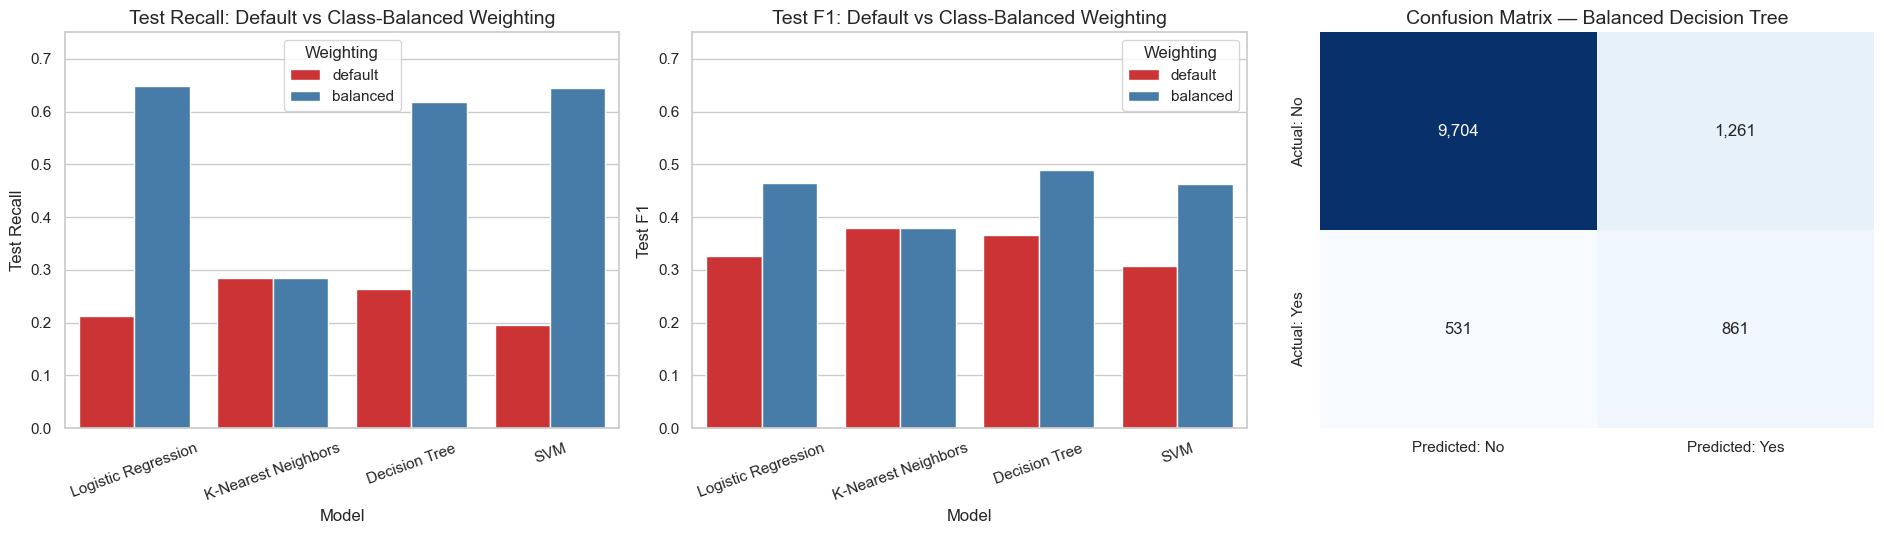

Best class-balanced model by F1: Decision Tree
  flags 17.2% of the 12,357 leads, reaching 61.9% of the 1,392 subscribers -> 3.6x lift over untargeted calling


In [191]:
# Direct before/after comparison on the two metrics we selected
comparison = (df_grid_nodur[['Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']]
              .merge(df_grid_balanced[['Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']],
                     on='Model', suffixes=(' (default)', ' (balanced)')))

comparison['Recall Change'] = (comparison['Test Recall (balanced)']
                               - comparison['Test Recall (default)']).round(4)
comparison['F1 Change'] = (comparison['Test F1 (balanced)']
                           - comparison['Test F1 (default)']).round(4)

print("=== Effect of class_weight='balanced' on the Pre-Call Models ===")
display(comparison[['Model', 'Test Recall (default)', 'Test Recall (balanced)', 'Recall Change',
                    'Test F1 (default)', 'Test F1 (balanced)', 'F1 Change']])

# Visualise the shift in recall and F1, plus the confusion matrix of the best balanced model
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, metric in zip(axes[:2], ['Recall', 'F1']):
    plot_df = comparison.melt(
        id_vars='Model',
        value_vars=[f'Test {metric} (default)', f'Test {metric} (balanced)'],
        var_name='Weighting', value_name='Score'
    )
    plot_df['Weighting'] = plot_df['Weighting'].str.extract(r'\((\w+)\)')
    sns.barplot(x='Model', y='Score', hue='Weighting', data=plot_df, palette='Set1', ax=ax)
    ax.set_title(f'Test {metric}: Default vs Class-Balanced Weighting')
    ax.set_xlabel('Model')
    ax.set_ylabel(f'Test {metric}')
    ax.set_ylim(0, 0.75)
    ax.tick_params(axis='x', rotation=20)

# Confusion matrix for the best balanced model by F1
best_balanced_name = df_grid_balanced.loc[df_grid_balanced['Test F1'].idxmax(), 'Model']
cm = confusion_matrix(y_test, best_models_balanced[best_balanced_name].predict(X_test_nodur))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
axes[2].set_title(f'Confusion Matrix — Balanced {best_balanced_name}')

plt.tight_layout()
plt.show()

print(f"Best class-balanced model by F1: {best_balanced_name}")

# Express that model in business terms: how much of the lead list it flags,
# how many subscribers that reaches, and how it compares to calling at random.
tn, fp, fn, tp = cm.ravel()
share_called = (tp + fp) / len(y_test)
share_captured = tp / y_test.sum()
print(f"  flags {share_called:.1%} of the {len(y_test):,} leads, "
      f"reaching {share_captured:.1%} of the {y_test.sum():,} subscribers "
      f"-> {share_captured / share_called:.1f}x lift over untargeted calling")

#### Interpretation: What Class Balancing Bought Us

**1. Recall roughly doubled to tripled for all three models that support class weighting.**

Each cell reads *default -> balanced (change)*:

| Model | Recall | F1 | Accuracy |
| :--- | :---: | :---: | :---: |
| Logistic Regression | 0.2134 -> **0.6480** (+0.4346) | 0.3260 -> 0.4651 (+0.1391) | 0.9006 -> 0.8321 (-0.0685) |
| Decision Tree | 0.2644 -> **0.6185** (+0.3541) | 0.3653 -> **0.4900** (+0.1247) | 0.8965 -> 0.8550 (-0.0415) |
| SVM | 0.1954 -> **0.6451** (+0.4497) | 0.3068 -> 0.4630 (+0.1562) | 0.9005 -> 0.8314 (-0.0691) |
| K-Nearest Neighbors | 0.2852 -> 0.2852 (0.0000) | 0.3785 -> 0.3785 (0.0000) | 0.8945 -> 0.8945 (0.0000) |

Logistic Regression (3.0x recall) and SVM (3.3x) gained most; the Decision Tree gained least in relative terms (2.3x) but makes the cheapest trade — the smallest accuracy give-up of the three — and finishes highest on F1 at **0.4900**, its best F1 score anywhere in this notebook without using `duration`. 

F1 score is a good balance, because it optimizes for both avoiding wasted calls (y='no') and successfully finding an eventual subscriber (y='yes').

**Based on this, the Decision Tree is our recommended model here.** At **0.6185 recall**, **0.85 accuracy** and **0.4900 F1**, it is both the highest F1 scored model and a practical one — you walk through a handful of comparisons, and it exposes a clear set of decision rules for a compliance review. The logistic regression is also interpretable, and while it scored higher in recall, it scored lower in F1 and accuracy. *The accuracy in both is understandably less than unbalanced models, however unbalanced models are not realistic to use here due to very limited ability to detect true positives*

*(attribution caveat: the grid search re-tunes under the new weights — the tree moves `max_depth` 10 -> 5 — so this is tuned-vs-tuned, not `class_weight` in isolation).*

**2. KNN cannot be rebalanced, and now finishes last.** With no `class_weight` parameter to set, KNN is tuned over the same `n_neighbors` grid as before, so its scores are **unchanged by construction** — it serves as the control in this comparison. That makes the contrast stark: KNN went from the *highest*-scoring model under default weighting to the *lowest* on F1 once the other three were corrected. 

**3. Accuracy fell, and that is the expected and acceptable trade.** The three rebalanced models drop from ~0.90 to ~0.83–0.86 accuracy (KNN, which could not be rebalanced, stays at 0.8945). As mentioned earlier the 0.8874 "predict no for everyone" baseline is itself worthless, because the whole point of this exercise is to predict "customers who will say yes". 

**4. What this buys in practice.** The recommended tree flags **17.2%** of the lead list and reaches **61.9%** of all subscribers.

### Visualizations & Diagnostics


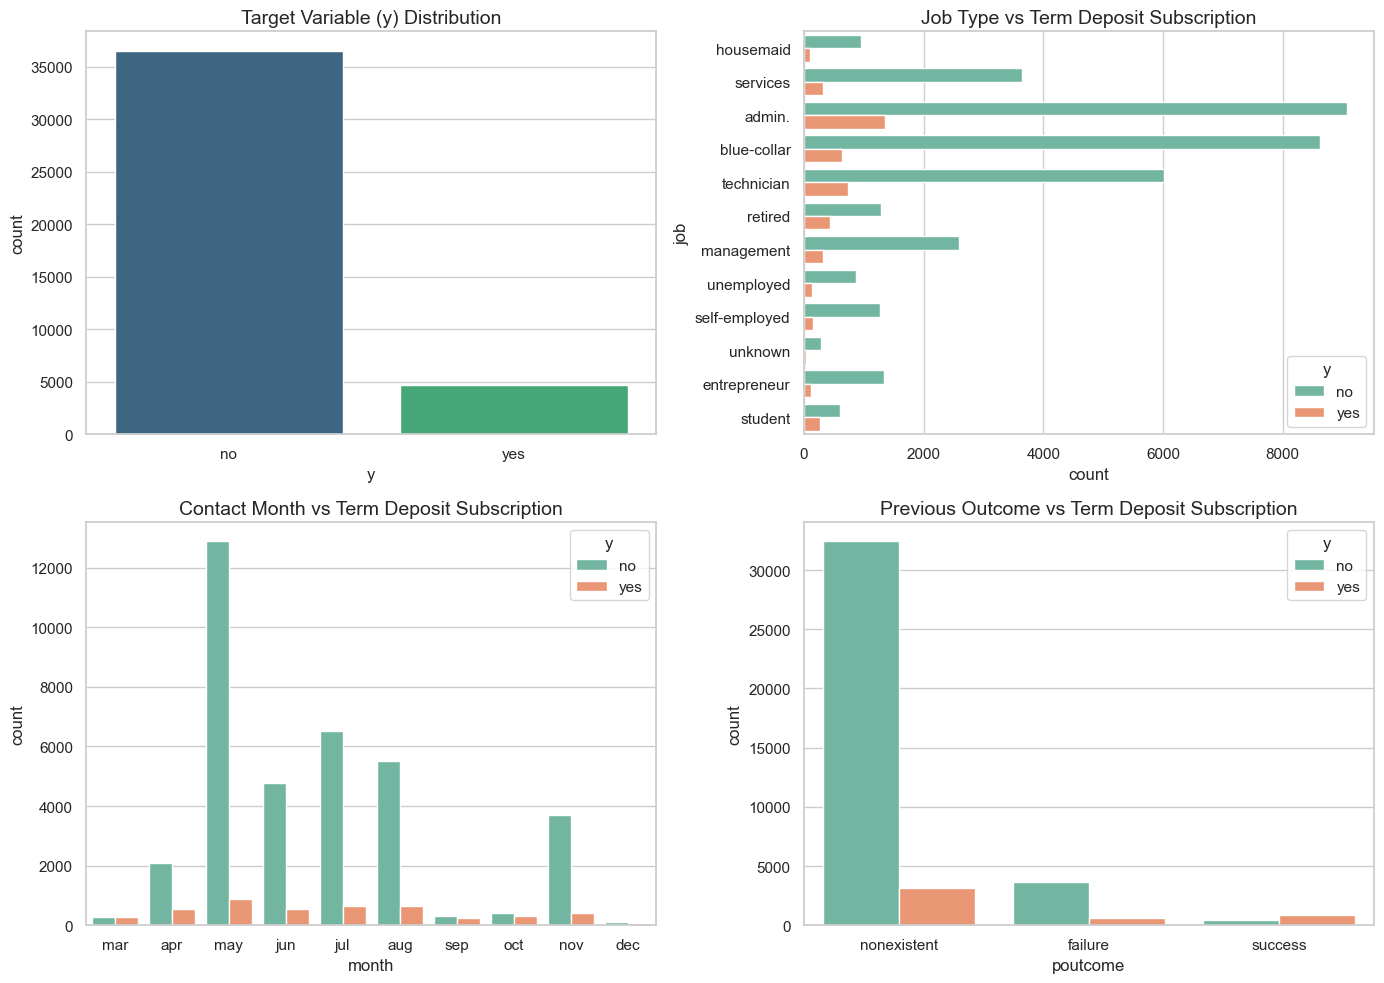

In [192]:
# Display Exploratory Data Analysis Plots (Generated dynamically)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
sns.countplot(x='y', data=df, hue='y', palette='viridis', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Target Variable (y) Distribution')

# Job type vs subscription
sns.countplot(y='job', hue='y', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Job Type vs Term Deposit Subscription')

# Contact month vs subscription
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(x='month', hue='y', data=df, palette='Set2', ax=axes[1, 0], order=month_order)
axes[1, 0].set_title('Contact Month vs Term Deposit Subscription')

# Previous campaign outcome vs subscription
sns.countplot(x='poutcome', hue='y', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Previous Outcome vs Term Deposit Subscription')

plt.tight_layout()
plt.show()


#### Distributions of the Continuous Features

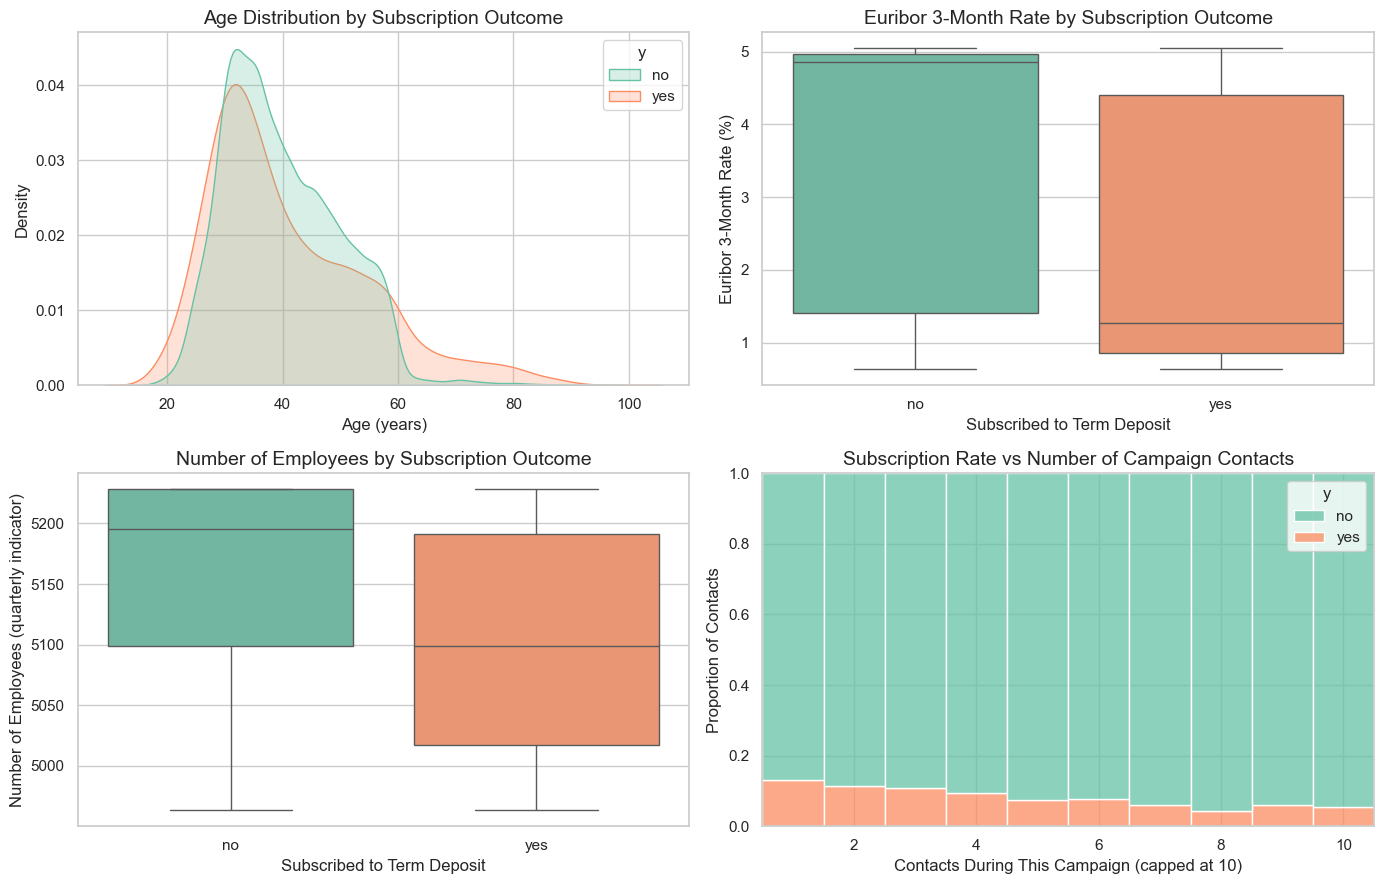

In [193]:
# Continuous feature distributions, split by subscription outcome.
# Densities are normalised within each class so the rare 'yes' group stays visible
# despite making up only 11.3% of the data.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Age: density by outcome reveals the young/senior split
sns.kdeplot(data=df, x='age', hue='y', common_norm=False, fill=True,
            palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Subscription Outcome')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Density')

# Euribor 3-month rate: the macro-economic driver
sns.boxplot(data=df, x='y', y='euribor3m', hue='y', palette='Set2',
            legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Euribor 3-Month Rate by Subscription Outcome')
axes[0, 1].set_xlabel('Subscribed to Term Deposit')
axes[0, 1].set_ylabel('Euribor 3-Month Rate (%)')

# Number of employees: the strongest single predictor in the tuned tree
sns.boxplot(data=df, x='y', y='nr.employed', hue='y', palette='Set2',
            legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Number of Employees by Subscription Outcome')
axes[1, 0].set_xlabel('Subscribed to Term Deposit')
axes[1, 0].set_ylabel('Number of Employees (quarterly indicator)')

# Campaign contacts: clipped at 10 because the long tail (max 56) hides the bulk of the data
sns.histplot(data=df[df['campaign'] <= 10], x='campaign', hue='y', multiple='fill',
             bins=10, discrete=True, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Subscription Rate vs Number of Campaign Contacts')
axes[1, 1].set_xlabel('Contacts During This Campaign (capped at 10)')
axes[1, 1].set_ylabel('Proportion of Contacts')

plt.tight_layout()
plt.show()

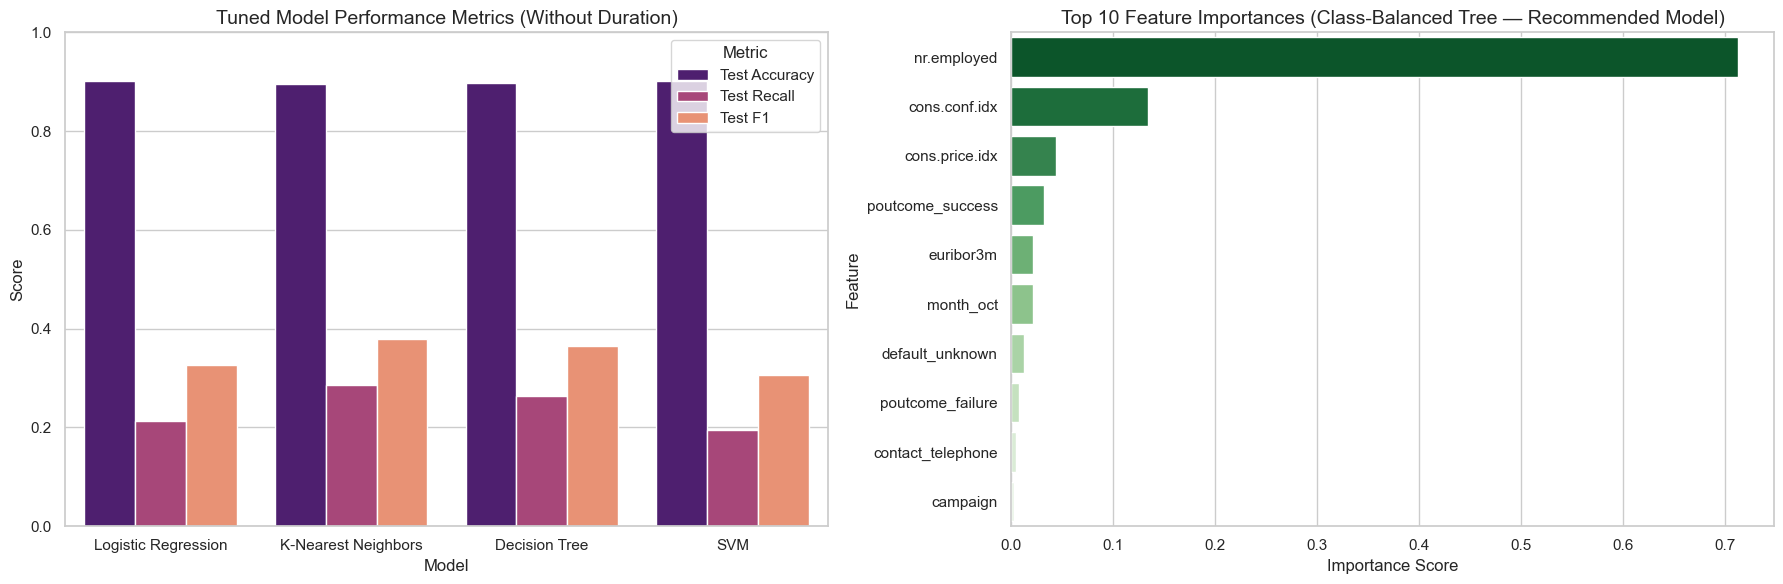

--- Feature importances of the recommended (class-balanced) tree ---


,Importance
nr.employed,0.7121
cons.conf.idx,0.1344
cons.price.idx,0.0440
poutcome_success,0.0321
euribor3m,0.0213
month_oct,0.0212
default_unknown,0.0124
poutcome_failure,0.0081
contact_telephone,0.0045
campaign,0.0032


--- Top 2 levels of the recommended (class-balanced) Decision Tree ---
|--- nr.employed <= -1.09
|   |--- poutcome_success <= 0.50
|   |   |--- contact_telephone <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- contact_telephone >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- poutcome_success >  0.50
|   |   |--- day_of_week_mon <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- day_of_week_mon >  0.50
|   |   |   |--- truncated branch of depth 3
|--- nr.employed >  -1.09
|   |--- cons.conf.idx <= -1.33
|   |   |--- default_unknown <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- default_unknown >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- cons.conf.idx >  -1.33
|   |   |--- cons.price.idx <= 0.66
|   |   |   |--- truncated branch of depth 3
|   |   |--- cons.price.idx >  0.66
|   |   |   |--- truncated branch of depth 3

Root split in real units: nr.employed <= 5,088
  at or below -> 4,964 contacts, 44.50%

In [194]:
# Display Model Evaluation & Feature Importance Plots (Generated dynamically)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Model Comparison (Test Accuracy, Recall, F1)
df_grid_nodur_melt = df_grid_nodur.melt(id_vars=['Model'], value_vars=['Test Accuracy', 'Test Recall', 'Test F1'], 
                                         var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=df_grid_nodur_melt, palette='magma', ax=axes[0])
axes[0].set_title('Tuned Model Performance Metrics (Without Duration)')
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')

# Plot 2: Feature importances of the RECOMMENDED model (class-balanced Decision Tree),
# so the chart describes the model we actually deploy.
dt_best_nodur = best_models_balanced['Decision Tree'].named_steps['clf']
cat_encoder_nodur = best_models_balanced['Decision Tree'].named_steps['preproc'].named_transformers_['cat']
encoded_cat_names_nodur = list(cat_encoder_nodur.get_feature_names_out(full_cat))
all_feature_names_nodur = full_nodur_num + encoded_cat_names_nodur

importances_nodur = pd.Series(dt_best_nodur.feature_importances_, index=all_feature_names_nodur).sort_values(ascending=False).head(10)
sns.barplot(x=importances_nodur.values, y=importances_nodur.index, hue=importances_nodur.index, palette='Greens_r', ax=axes[1], legend=False)
axes[1].set_title('Top 10 Feature Importances (Class-Balanced Tree — Recommended Model)')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

# Print the exact values behind the chart, so the importances quoted in the Findings are sourced
print("--- Feature importances of the recommended (class-balanced) tree ---")
display(importances_nodur.round(4).to_frame('Importance'))

# Show the top of the recommended tree, so its decision rules are auditable rather than asserted.
from sklearn.tree import export_text
print("--- Top 2 levels of the recommended (class-balanced) Decision Tree ---")
print(export_text(dt_best_nodur, feature_names=all_feature_names_nodur, max_depth=2))

# Numeric features were standardised, so the thresholds above are z-scores.
# Translate the root split back into real units to make it readable.
num_scaler = best_models_balanced['Decision Tree'].named_steps['preproc'].named_transformers_['num']
root_feature = all_feature_names_nodur[dt_best_nodur.tree_.feature[0]]
root_threshold = dt_best_nodur.tree_.threshold[0]
if root_feature in full_nodur_num:
    j = full_nodur_num.index(root_feature)
    raw_threshold = num_scaler.mean_[j] + root_threshold * num_scaler.scale_[j]
    below = df[df[root_feature] <= raw_threshold]
    above = df[df[root_feature] > raw_threshold]
    print(f"Root split in real units: {root_feature} <= {raw_threshold:,.0f}")
    print(f"  at or below -> {len(below):,} contacts, {below['target'].mean()*100:.2f}% subscribe")
    print(f"  above       -> {len(above):,} contacts, {above['target'].mean()*100:.2f}% subscribe")

#### Are the economic indicators correlated ?

There are several economic indicators in the data, it makes sense to explore correlations between them. 

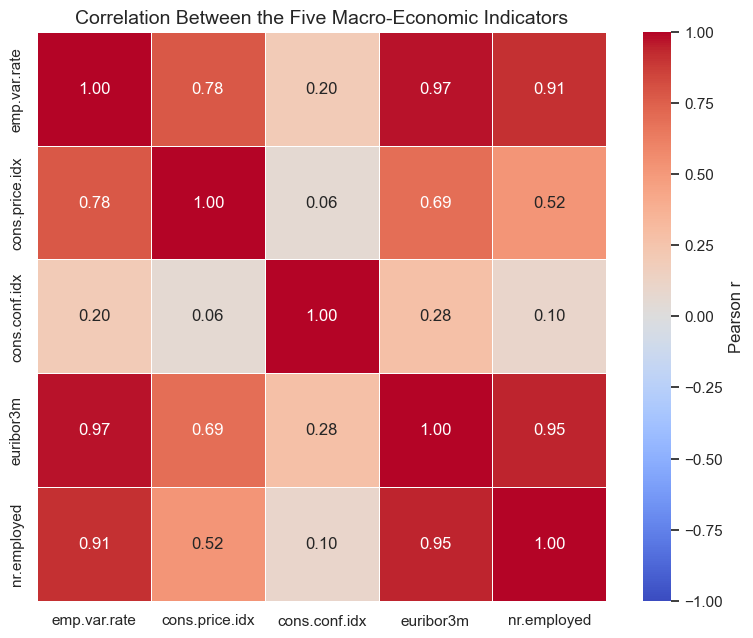

Within the 'economic climate' block:
  emp.var.rate     vs euribor3m        r = 0.97
  emp.var.rate     vs nr.employed      r = 0.91
  euribor3m        vs nr.employed      r = 0.95

cons.conf.idx vs the other four: r = 0.06 to 0.28


In [195]:
# Correlation among the five social/economic context attributes.
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
econ_corr = df[econ_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(econ_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Between the Five Macro-Economic Indicators')
plt.tight_layout()
plt.show()

# The three indicators the coefficient discussion treats as one block, vs. the odd one out.
block = ['emp.var.rate', 'euribor3m', 'nr.employed']
pairs = econ_corr.loc[block, block].where(np.triu(np.ones((3, 3)), k=1).astype(bool)).stack()
print("Within the 'economic climate' block:")
for (a, b), r in pairs.items():
    print(f"  {a:16s} vs {b:16s} r = {r:.2f}")
print(f"\ncons.conf.idx vs the other four: r = "
      f"{econ_corr.loc['cons.conf.idx'].drop('cons.conf.idx').min():.2f} "
      f"to {econ_corr.loc['cons.conf.idx'].drop('cons.conf.idx').max():.2f}")

#### Exploring feature impact via the Logistic Regression Coefficients

--- Top 10 features INCREASING the odds of subscription ---


,Feature,Coefficient,Odds Ratio
0,month_mar,1.252,3.496
1,poutcome_success,1.017,2.764
2,cons.price.idx,0.999,2.716
3,euribor3m,0.655,1.924
4,month_aug,0.468,1.597
5,education_illiterate,0.462,1.587
6,month_dec,0.421,1.523
7,job_retired,0.382,1.465
8,marital_unknown,0.363,1.437
9,contact_cellular,0.332,1.394


--- Top 10 features DECREASING the odds of subscription ---


,Feature,Coefficient,Odds Ratio
0,emp.var.rate,-2.194,0.111
1,month_jun,-0.728,0.483
2,poutcome_failure,-0.716,0.489
3,month_may,-0.602,0.547
4,month_nov,-0.570,0.566
5,contact_telephone,-0.282,0.754
6,poutcome_nonexistent,-0.251,0.778
7,month_apr,-0.195,0.823
8,education_professional.course,-0.162,0.851
9,marital_divorced,-0.153,0.858


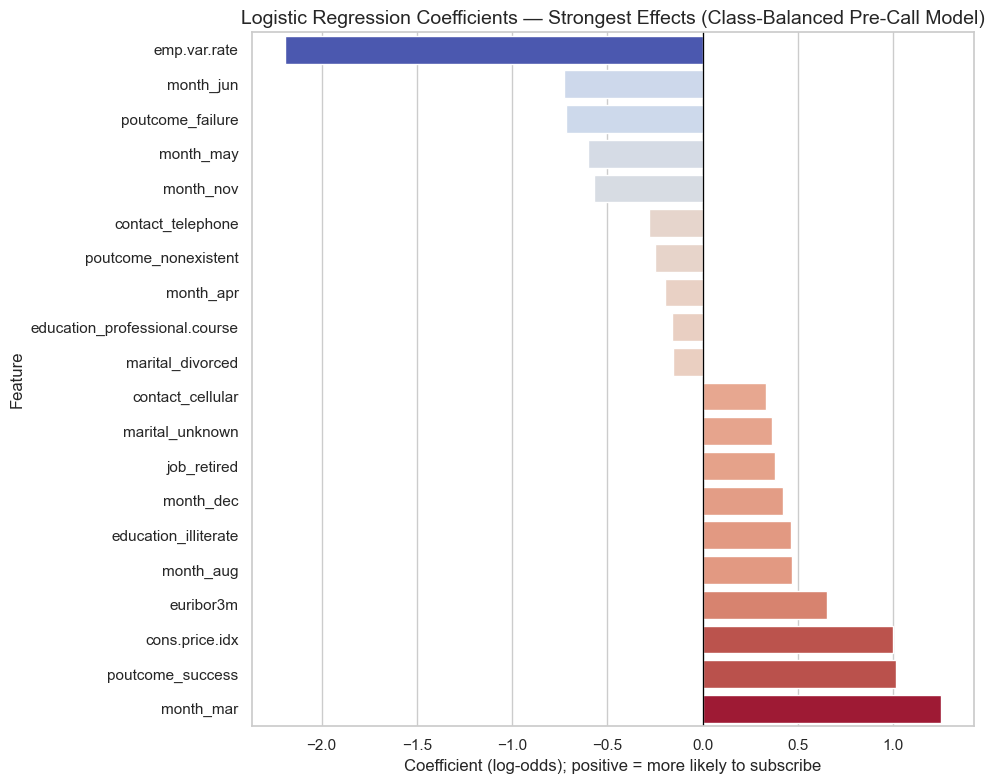

In [196]:
# While logistic regression was not our chosen model, it still scored well. Interpret its class-balanced coefficients (the rebalanced pre-call model,
# so this diagnostic describes the same configuration we recommend).
# Numeric features were standardised, so an odds ratio is the multiplicative change in the
# odds of subscribing per one standard deviation increase. One-hot categorical features are
# read relative to the other levels of that same variable.
lr_best_nodur = best_models_balanced['Logistic Regression']
lr_feature_names = full_nodur_num + list(
    lr_best_nodur.named_steps['preproc'].named_transformers_['cat'].get_feature_names_out(full_cat)
)

coef_df = pd.DataFrame({
    'Feature': lr_feature_names,
    'Coefficient': lr_best_nodur.named_steps['clf'].coef_[0]
})
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Coefficient', ascending=False).round(3)

print("--- Top 10 features INCREASING the odds of subscription ---")
display(coef_df.head(10).reset_index(drop=True))
print("--- Top 10 features DECREASING the odds of subscription ---")
display(coef_df.tail(10).sort_values('Coefficient').reset_index(drop=True))

# Visualise the ten strongest effects in each direction
top_coefs = pd.concat([coef_df.head(10), coef_df.tail(10)]).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_coefs,
            hue='Coefficient', palette='coolwarm', legend=False, ax=ax)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_title('Logistic Regression Coefficients — Strongest Effects (Class-Balanced Pre-Call Model)')
ax.set_xlabel('Coefficient (log-odds); positive = more likely to subscribe')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

#### Interpretation of Coefficients:
Unlike the Decision Tree's feature importances (which show only *how much* a feature matters), the Logistic Regression coefficients show **direction** as well as magnitude. These are the coefficients of the class-balanced **Logistic Regression** — the same weighting as the recommended tree, though a different algorithm. We use it as an explanatory companion rather than the deployed model,so its account of *which direction* each factor pushes is a credible read on the same underlying signal. 

1. **Employment variation rate dominates** (`emp.var.rate`, coefficient **-2.194**, odds ratio **0.111**): Deposit appetite collapses when the labour market is expanding and rises when it contracts.
2. **Prior campaign success is the strongest customer-level driver** (`poutcome_success`, odds ratio **2.764**): a client who subscribed in an earlier campaign has roughly **2.8x** the odds of subscribing again.
3. **The economic data must be read together, not feature by feature.** `cons.price.idx` (odds ratio **2.716**) and `euribor3m` (odds ratio **1.924**) carry large *positive* coefficients, which looks contradictory next to `emp.var.rate`. `emp.var.rate`, `euribor3m` and `nr.employed` are almost collinear (pairwise r of 0.91-0.97), so the model distributes one underlying "economic climate" effect across them with offsetting signs. (`cons.conf.idx` is the exception — it correlates only 0.06-0.28 with the others and does carry independent information, which is why the tree gives it 13.4% importance.) The individual signs within this block are therefore not independently interpretable — the Decision Tree's importance ranking (`nr.employed` at 71.2%) is the more reliable read on which economic signal carries the information.
4. **March is the standout month** (`month_mar`, odds ratio **3.496**): contacts made in March have roughly 3.5x the odds of subscribing, while June, May, and November all suppress the odds (odds ratios of 0.483, 0.547, and 0.566 respectively).
5. **Channel matters, in both directions** (`contact_cellular` odds ratio **1.394**, `contact_telephone` odds ratio **0.754**): reaching a client on a mobile raises the odds of subscription, and reaching them on a landline lowers it. 
6. **Demographics corroborate the descriptive statistics**: `job_retired` carries a positive coefficient (odds ratio **1.465**), independently confirming the elevated retiree conversion rate observed in the exploratory analysis above.

## Findings, Insights & Next Steps

### 1. Key Findings & Model Performance (Technical)
* **Why Accuracy Can Be Misleading**: Since ~88.7% of customers decline deposit offers, a basic approach of predicting "no" for everyone achieves 88.7% accuracy—but fails to catch a single customer. Evaluating models on **Recall** (percentage of interested customers caught) and **F1-Score** (overall campaign efficiency) provides a true measure of success.
* **Correcting the Imbalance was a major Improvement**: Under default weighting, no model exceeded **0.2852 Recall** — K-Nearest Neighbors led, with the Decision Tree at 0.2644. Applying `class_weight='balanced'` **doubled to tripled recall** for the three models that support it (3.0x for Logistic Regression, 3.3x for SVM, 2.3x for the Decision Tree), and lifted F1 for all three. 
* **Best Model Overall**: The **class-balanced tuned Decision Tree** (`max_depth=5`, `criterion='gini'`, `class_weight='balanced'`) is the recommended model — the highest F1 combined with accuracy scores of any model tested without using `duration`.
* **K-Nearest Neighbors Cannot Be Rebalanced**: KNN has no `class_weight` parameter to set, so it is tuned over the same `n_neighbors` grid in both runs and acts as the control. It went from the best-scoring model under default weighting to the weakest on F1 (0.3785) once the other three were corrected.
* **Duration Confirms the Warning in the Data Dictionary**: Including `duration` lifts the Decision Tree's recall from 0.2644 to 0.5812 and F1 from 0.3653 to 0.5922. Since call duration is only known *after* a call ends, those stronger numbers are a benchmark ceiling and cannot be used to build a call list. All deployment conclusions above rest on the without-duration models.

---

### 2. Key Drivers & Customer Profiles

#### A. Market & Campaign Drivers
1. **Economic Climate is a strong Signal**: `nr.employed` (number of employees) alone accounts for **71.2%** of the recommended tree's splitting power, and the Logistic Regression assigns its single largest coefficient to `emp.var.rate` (employment variation rate, odds ratio **0.111**). Customer interest in fixed deposits rises sharply when the labour market weakens. *Caveat: `emp.var.rate`, `euribor3m` and `nr.employed` are near-collinear, so read them as one combined "economic climate" effect rather than three independent drivers.*
2. **Prior Campaign Outcome**: Clients who subscribed in an earlier campaign convert at **65.11%**, versus **14.23%** for those who previously declined and **8.83%** for those never contacted before.
3. **Channel and Timing**: Contacting a client on a mobile raises the odds of subscription (odds ratio **1.394**) while a landline lowers them (odds ratio **0.754**), and March contacts carry the single highest month effect (odds ratio **3.496**).

#### B. High-Converting Customer Profiles
1. **Seniors & Retirees**: Customers **over 60** subscribe at **45.5%** and retirees at **25.2%** (versus the 11.3% overall average), as fixed-rate deposits match their need for safe, stable income. *Note: the over-60 band contains only 910 contacts, so this rate is based on a small segment and should be confirmed before large-scale targeting.*
2. **Students**: Students convert at **31.4%** (nearly 3x the overall average), whereas blue-collar workers convert at **6.9%**.

---

### 3. Analysis improvement opportunities (Technical)

1. **Widen the Hyperparameter Grids**: In the recommended run, two of the four models selected a value at the edge of their search grid (`n_neighbors=5` for KNN, the lowest offered; `C=1.0` for SVM, the highest offered), which suggests the optimum may lie outside the range searched. KNN's grid in particular contains only two values.
2. **Add Cost-Based Evaluation**: Recall and F1 weight false positives and false negatives equally. In real life, it is possible that one is more expensive than the other. Working with the call centre to attach a real dollar/euro cost to a wasted call and a real value to a captured deposit would let us optimise expected profit directly, which is what the business actually cares about.

### 4. Next steps, recommendations & action items for Bank Leadership (non technical)

1. **Focus Calling Lists on High-Value Profiles**: Prioritize calling seniors, retirees, students, and — above all — customers who subscribed in a previous campaign, rather than reaching out to database contacts at random.
2. **Always Call Mobiles Where Available**: Mobile contacts convert at **14.74%** against **5.23%** on a landline.
3. **Time Marketing Campaigns With Market Conditions**: Increase telemarketing efforts when employment is contracting and money is cheap: subscribers were reached at a **median** `euribor3m` of **1.27** versus **4.86** for non-subscribers.
4. **Run a Pilot Campaign**: Test the smart call-list ranking with a small team of call center agents to measure the actual increase in deposit sign-ups before rolling it out full-scale.